In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import os
import corner

plots_dir = "plotsv7"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)  


mcmcfit_dir = "mcmc_fitsv7"
if not os.path.exists(mcmcfit_dir):
    os.makedirs(mcmcfit_dir)

#df = pd.read_csv('GaiaParallax/TotalAvg_Good_Single_Fits_s_0.33_level_0(2).csv')
dff1 = pd.read_csv('/Users/himanshuverma/Downloads/TotalAvg_Good_Single_Fits_s_0.33_level_0(3).csv')
dff2 = pd.read_csv('/Users/himanshuverma/Downloads/TotalAvg_Good_Single_Fits_s_0.55_level_0(1).csv')

#merge the two dataframes 
df = pd.concat([dff1, dff2], ignore_index=True).sort_values(by=['Latitude', 'Long']).reset_index(drop=True)




df_u = df.drop_duplicates(keep='last')  # Keep last occurrence

unique_latitudes = df['Latitude'].unique()
print("Unique latitudes in the data:", unique_latitudes)


Unique latitudes in the data: [-10.    -9.45  -8.9   -8.35  -7.8   -7.25  -6.7   -6.15  -6.15  -6.
  -5.67  -5.67  -5.34  -5.01  -4.68  -4.35  -4.02  -3.69  -3.36  -3.03
  -2.7   -2.7   -2.37   2.25   2.58   2.91   3.24   3.57   3.9    4.23
   4.56   4.89]


In [3]:


labels = ['Bar Angle (°)', 'Zero Point (mas)', 'sigma_x (kpc)', 'sigma_y (kpc)', 'sigma_z (kpc)', 'r_E (kpc)']
n_walkers = 12
n_steps = 2000
n_burn = 100  
fit_type = 'AllPriors'  # or 'sigZrEPriors'
n_params = len(labels)
    
for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]
    try:
        samples = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCsamples_b_{fixed_b_deg:.2f}.npy'))
        print(f"Loaded MCMC samples for b = {fixed_b_deg:.2f}°")
        #chains = np.load(os.path.join(mcmcfit_dir,f'{fit_type}_MCMCsamples_b_{fixed_b_deg:.2f}.npy'))
        #samples = chains[n_burn:, :, :].reshape((-1, n_params))
        #median values for each parameter
        median_values = np.median(samples, axis=0)
        truths = [median_values[0], median_values[1], median_values[2], median_values[3], median_values[4], median_values[5]]  # bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
        #draw corner plot for this b
        fig = corner.corner(
                    samples,
                    labels=labels,
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True,
                    title_kwargs={"fontsize": 12},
                    truths=truths)
        '''                    range=[
                                (0, 30),      # bar_angle
                                (-0.05, 0.05),  # zp
                                (0.1, 1.5),   # sigma_x
                                (0.05, 0.5),  # sigma_y
                                (0.05, 0.5),  # sigma_z
                                (7.0, 9),  # r_E
                            ]
        '''      
        xlims = [(0, 90), (-0.05, 0.05), (0.1, 2), (0.05, 1), (0.05, 0.5), (7.0, 9.0)]# bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
        axes = np.array(fig.axes).reshape((6, 6))
        for i in range(6):
            axes[i, i].set_xlim(xlims[i])          # diagonal histograms
            for j in range(i):
                axes[i, j].set_xlim(xlims[j])       # off-diagonal x-axis
                axes[i, j].set_ylim(xlims[i])       # off-diagonal y-axis

        fig.suptitle(f'MCMC Corner Plot for b = {fixed_b_deg:.2f}°', fontsize=16)
        plt.savefig(os.path.join(plots_dir, f'Corner{fit_type}_b_{fixed_b_deg:.2f}.png'))
        plt.close()
        print(np.shape(samples))
        n_params = len(labels)
        chains = samples.reshape((n_steps-n_burn, n_walkers, n_params))    

        fig, axes = plt.subplots(n_params, 1, figsize=(10, 2*n_params), sharex=True)
        
        for i in range(n_params):
            ax = axes[i]
            ax.plot(chains[:, :, i], alpha=0.5)
            ax.set_ylabel(labels[i])        
        axes[-1].set_xlabel("Step Number")

        fig.suptitle(f'{fit_type}: for b = {fixed_b_deg:.2f}°', fontsize=16)
        plt.savefig(os.path.join(plots_dir, f'Chains{fit_type}_b_{fixed_b_deg:.2f}.png'))
        plt.close()

    except FileNotFoundError:
        print(f"File not found for b = {fixed_b_deg:.2f}°. Skipping.")
        continue

File not found for b = -10.00°. Skipping.
Loaded MCMC samples for b = -9.45°
(22800, 6)
Loaded MCMC samples for b = -8.90°
(22800, 6)
Loaded MCMC samples for b = -8.35°
(22800, 6)
Loaded MCMC samples for b = -7.80°
(22800, 6)
Loaded MCMC samples for b = -7.25°
(22800, 6)
Loaded MCMC samples for b = -6.70°
(22800, 6)
Loaded MCMC samples for b = -6.15°
(22800, 6)
Loaded MCMC samples for b = -6.15°
(22800, 6)
Loaded MCMC samples for b = -6.00°
(22800, 6)
Loaded MCMC samples for b = -5.67°
(22800, 6)
Loaded MCMC samples for b = -5.67°
(22800, 6)
Loaded MCMC samples for b = -5.34°
(22800, 6)
Loaded MCMC samples for b = -5.01°
(22800, 6)
Loaded MCMC samples for b = -4.68°
(22800, 6)
Loaded MCMC samples for b = -4.35°
(22800, 6)
Loaded MCMC samples for b = -4.02°
(22800, 6)
Loaded MCMC samples for b = -3.69°
(22800, 6)
Loaded MCMC samples for b = -3.36°
(22800, 6)
Loaded MCMC samples for b = -3.03°
(22800, 6)
Loaded MCMC samples for b = -2.70°
(22800, 6)
Loaded MCMC samples for b = -2.70°
(22

In [4]:
import os
import corner


labels = ['Bar Angle (°)', 'Zero Point (mas)', 'sigma_x (kpc)', 'sigma_y (kpc)', 'sigma_z (kpc)', 'r_E (kpc)']
n_walkers = 12
n_steps = 2000
n_burn = 100  
fit_type =  'sigZrEPriors'

    
for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]
    try:
        samples = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCsamples_b_{fixed_b_deg:.2f}.npy'))
        print(f"Loaded MCMC samples for b = {fixed_b_deg:.2f}°")
        #median values for each parameter
        median_values = np.median(samples, axis=0)
        truths = [median_values[0], median_values[1], median_values[2], median_values[3], median_values[4], median_values[5]]  # bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
        #draw corner plot for this b
        fig = corner.corner(
                    samples,
                    labels=labels,
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True,
                    title_kwargs={"fontsize": 12},
                    truths=truths)
        '''                    range=[
                                (0, 30),      # bar_angle
                                (-0.05, 0.05),  # zp
                                (0.1, 1.5),   # sigma_x
                                (0.05, 0.5),  # sigma_y
                                (0.05, 0.5),  # sigma_z
                                (7.0, 9),  # r_E
                            ]
        '''      
        xlims = [(0, 90), (-0.05, 0.05), (0.1, 2), (0.05, 1), (0.05, 0.5), (7.0, 9.0)]# bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
        axes = np.array(fig.axes).reshape((6, 6))
        for i in range(6):
            axes[i, i].set_xlim(xlims[i])          # diagonal histograms
            for j in range(i):
                axes[i, j].set_xlim(xlims[j])       # off-diagonal x-axis
                axes[i, j].set_ylim(xlims[i])       # off-diagonal y-axis

        fig.suptitle(f'{fit_type}: for b = {fixed_b_deg:.2f}°', fontsize=16)
        plt.savefig(os.path.join(plots_dir, f'Corner{fit_type}_b_{fixed_b_deg:.2f}.png'))
        plt.close()
        print(np.shape(samples))
        n_params = len(labels)
        #chains = samples.reshape((n_steps-n_burn, n_walkers, n_params))    
        chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_b_{fixed_b_deg:.2f}.npy'))
        fig, axes = plt.subplots(n_params, 1, figsize=(10, 2*n_params), sharex=True)
        
        for i in range(n_params):
            ax = axes[i]
            ax.plot(chains[:, :, i], alpha=0.5)
            ax.axvline(n_burn, color='red', linestyle='--')  # burn-in line
            ax.set_ylabel(labels[i])        
        axes[-1].set_xlabel("Step Number")

        fig.suptitle(f'{fit_type}: for b = {fixed_b_deg:.2f}°', fontsize=16)
        plt.savefig(os.path.join(plots_dir, f'Chains{fit_type}_b_{fixed_b_deg:.2f}.png'))
        plt.close()

    except FileNotFoundError:
        print(f"File not found for b = {fixed_b_deg:.2f}°. Skipping.")
        continue

File not found for b = -10.00°. Skipping.
Loaded MCMC samples for b = -9.45°
(22800, 6)
Loaded MCMC samples for b = -8.90°
(22800, 6)
Loaded MCMC samples for b = -8.35°
(22800, 6)
Loaded MCMC samples for b = -7.80°
(22800, 6)
Loaded MCMC samples for b = -7.25°
(22800, 6)
Loaded MCMC samples for b = -6.70°
(22800, 6)
Loaded MCMC samples for b = -6.15°
(22800, 6)
Loaded MCMC samples for b = -6.15°
(22800, 6)
Loaded MCMC samples for b = -6.00°
(22800, 6)
Loaded MCMC samples for b = -5.67°
(22800, 6)
Loaded MCMC samples for b = -5.67°
(22800, 6)
Loaded MCMC samples for b = -5.34°
(22800, 6)
Loaded MCMC samples for b = -5.01°
(22800, 6)
Loaded MCMC samples for b = -4.68°
(22800, 6)
Loaded MCMC samples for b = -4.35°
(22800, 6)
Loaded MCMC samples for b = -4.02°
(22800, 6)
Loaded MCMC samples for b = -3.69°
(22800, 6)
Loaded MCMC samples for b = -3.36°
(22800, 6)
Loaded MCMC samples for b = -3.03°
(22800, 6)
Loaded MCMC samples for b = -2.70°
(22800, 6)
Loaded MCMC samples for b = -2.70°
(22

Loaded MCMC samples for b = 2.25°
(22800, 6)
Loaded MCMC samples for b = 2.58°
(22800, 6)
Loaded MCMC samples for b = 2.91°
(22800, 6)
Loaded MCMC samples for b = 3.24°
(22800, 6)
Loaded MCMC samples for b = 3.57°
(22800, 6)
Loaded MCMC samples for b = 3.90°
(22800, 6)
Loaded MCMC samples for b = 4.23°
(22800, 6)
Loaded MCMC samples for b = 4.56°
(22800, 6)
Loaded MCMC samples for b = 4.89°
(22800, 6)


In [5]:
import os
import corner

labels = ['Bar Angle (°)', 'Zero Point (mas)', 'sigma_x (kpc)', 'sigma_y (kpc)', 'sigma_z (kpc)', 'r_E (kpc)']
n_walkers = 12
n_steps = 2000
n_burn = 600  
fit_type =  'sigZrEPriors'

    
try:
    #samples = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCsamples_All_b.npy'))
    print(f"Loaded MCMC samples for All latitudes and {fit_type}")
    #median values for each parameter
    chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_All_b.npy'))
    samples = chains[n_burn:, :, :].reshape((-1, n_params))
    median_values = np.median(samples, axis=0)
    truths = [median_values[0], median_values[1], median_values[2], median_values[3], median_values[4], median_values[5]]  # bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
    #draw corner plot for this b
    fig = corner.corner(
                samples,
                labels=labels,
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 12},
                truths=truths)
    '''                    range=[
                            (0, 30),      # bar_angle
                            (-0.05, 0.05),  # zp
                            (0.1, 1.5),   # sigma_x
                            (0.05, 0.5),  # sigma_y
                            (0.05, 0.5),  # sigma_z
                            (7.0, 9),  # r_E
                        ]
    '''      
    xlims = [(0, 90), (-0.05, 0.05), (0.1, 2), (0.05, 1), (0.05, 0.5), (7.0, 9.0)]# bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
    axes = np.array(fig.axes).reshape((6, 6))
    #for i in range(6):
    #    axes[i, i].set_xlim(xlims[i])          # diagonal histograms
    #    for j in range(i):
    #        axes[i, j].set_xlim(xlims[j])       # off-diagonal x-axis
    #        axes[i, j].set_ylim(xlims[i])       # off-diagonal y-axis

    fig.suptitle(f'{fit_type}: for All latitudes', fontsize=16)
    plt.savefig(os.path.join(plots_dir, f'Corner{fit_type}_All_b.png'))
    plt.close()
    print(np.shape(samples))
    n_params = len(labels)
    #chains = samples.reshape((n_steps-n_burn, n_walkers, n_params))    
    chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_All_b.npy'))
    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2*n_params), sharex=True)
    
    for i in range(n_params):
        ax = axes[i]
        ax.plot(chains[:, :, i], alpha=0.5)
        ax.axvline(n_burn, color='red', linestyle='--')  # burn-in line
        ax.set_ylabel(labels[i])        
    axes[-1].set_xlabel("Step Number")

    fig.suptitle(f'{fit_type}: for All latitudes', fontsize=16)
    plt.savefig(os.path.join(plots_dir, f'Chains{fit_type}_All_b.png'))
    plt.close()

except FileNotFoundError:
    print(f"File not found for All latitudes and {fit_type}. Skipping.")


Loaded MCMC samples for All latitudes and sigZrEPriors
(16800, 6)


In [6]:
import os
import corner


labels = ['Bar Angle (°)', 'Zero Point (mas)', 'sigma_x (kpc)', 'sigma_y (kpc)', 'sigma_z (kpc)', 'r_E (kpc)']
n_walkers = 12
n_steps = 2000
n_burn = 600  
fit_type =  'AllPriors'  # or 'sigZrEPriors'
n_params= len(labels)
    
try:
    #samples = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCsamples_All_b.npy'))
    #make samples from chains
    chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_All_b.npy'))
    samples = chains[n_burn:, :, :].reshape((-1, n_params))
    print(f"Loaded MCMC samples for All latitudes and {fit_type}")
    #median values for each parameter
    median_values = np.median(samples, axis=0)
    truths = [median_values[0], median_values[1], median_values[2], median_values[3], median_values[4], median_values[5]]  # bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
    #draw corner plot for this b
    fig = corner.corner(
                samples,
                labels=labels,
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 12},
                truths=truths)
    '''                    range=[
                            (0, 30),      # bar_angle
                            (-0.05, 0.05),  # zp
                            (0.1, 1.5),   # sigma_x
                            (0.05, 0.5),  # sigma_y
                            (0.05, 0.5),  # sigma_z
                            (7.0, 9),  # r_E
                        ]
    '''      
    xlims = [(0, 90), (-0.05, 0.05), (0.1, 2), (0.05, 1), (0.05, 0.5), (7.0, 9.0)]# bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
    axes = np.array(fig.axes).reshape((6, 6))
    #for i in range(6):
        #axes[i, i].set_xlim(xlims[i])          # diagonal histograms
    #    for j in range(i):
            #axes[i, j].set_xlim(xlims[j])       # off-diagonal x-axis
            #axes[i, j].set_ylim(xlims[i])       # off-diagonal y-axis

    fig.suptitle(f'{fit_type}: for All latitudes', fontsize=16)
    plt.savefig(os.path.join(plots_dir, f'Corner{fit_type}_All_b.png'))
    plt.close()
    print(np.shape(samples))
    n_params = len(labels)
    #chains = samples.reshape((n_steps-n_burn, n_walkers, n_params))    
    chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_All_b.npy'))
    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2*n_params), sharex=True)
    
    for i in range(n_params):
        ax = axes[i]
        ax.plot(chains[:, :, i], alpha=0.5)
        ax.axvline(n_burn, color='red', linestyle='--')  # burn-in line
        ax.set_ylabel(labels[i])        
    axes[-1].set_xlabel("Step Number")

    fig.suptitle(f'{fit_type}: for All latitudes', fontsize=16)
    plt.savefig(os.path.join(plots_dir, f'Chains{fit_type}_All_b.png'))
    plt.close()

except FileNotFoundError:
    print(f"File not found for All latitudes and {fit_type}. Skipping.")


Loaded MCMC samples for All latitudes and AllPriors
(16800, 6)


In [7]:
import os
import corner


labels = ['Bar Angle (°)', 'Zero Point (mas)', 'sigma_x (kpc)', 'sigma_y (kpc)', 'sigma_z (kpc)', 'r_E (kpc)']
n_walkers = 12
n_steps = 2000
n_burn = 600  
fit_type =  'rEPriors'#'AllPriors'  # or 'sigZrEPriors'

    
try:
    #samples = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCsamples_All_b.npy'))
    print(f"Loaded MCMC samples for All latitudes and {fit_type}")
    chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_All_b.npy'))
    samples = chains[n_burn:, :, :].reshape((-1, n_params))
    #median values for each parameter
    median_values = np.median(samples, axis=0)
    truths = [median_values[0], median_values[1], median_values[2], median_values[3], median_values[4], median_values[5]]  # bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
    #draw corner plot for this b
    fig = corner.corner(
                samples,
                labels=labels,
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 12},
                truths=truths)
    '''                    range=[
                            (0, 30),      # bar_angle
                            (-0.05, 0.05),  # zp
                            (0.1, 1.5),   # sigma_x
                            (0.05, 0.5),  # sigma_y
                            (0.05, 0.5),  # sigma_z
                            (7.0, 9),  # r_E
                        ]
    '''      
    xlims = [(0, 90), (-0.05, 0.05), (0.1, 2), (0.05, 1), (0.05, 0.5), (7.0, 9.0)]# bar_angle, zp, sigma_x, sigma_y, sigma_z, r_E
    axes = np.array(fig.axes).reshape((6, 6))
    #for i in range(6):
    #    axes[i, i].set_xlim(xlims[i])          # diagonal histograms
    #    for j in range(i):
    #        axes[i, j].set_xlim(xlims[j])       # off-diagonal x-axis
    #        axes[i, j].set_ylim(xlims[i])       # off-diagonal y-axis

    fig.suptitle(f'{fit_type}: for All latitudes', fontsize=16)
    plt.savefig(os.path.join(plots_dir, f'Corner{fit_type}_All_b.png'))
    plt.close()
    print(np.shape(samples))
    n_params = len(labels)
    #chains = samples.reshape((n_steps-n_burn, n_walkers, n_params))    
    chains = np.load(os.path.join(mcmcfit_dir, f'{fit_type}_MCMCchains_All_b.npy'))
    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2*n_params), sharex=True)
    
    for i in range(n_params):
        ax = axes[i]
        ax.plot(chains[:, :, i], alpha=0.5)
        ax.axvline(n_burn, color='red', linestyle='--')  # burn-in line
        ax.set_ylabel(labels[i])        
    axes[-1].set_xlabel("Step Number")

    fig.suptitle(f'{fit_type}: for All latitudes', fontsize=16)
    plt.savefig(os.path.join(plots_dir, f'Chains{fit_type}_All_b.png'))
    plt.close()

except FileNotFoundError:
    print(f"File not found for All latitudes and {fit_type}. Skipping.")


Loaded MCMC samples for All latitudes and rEPriors


(16800, 6)


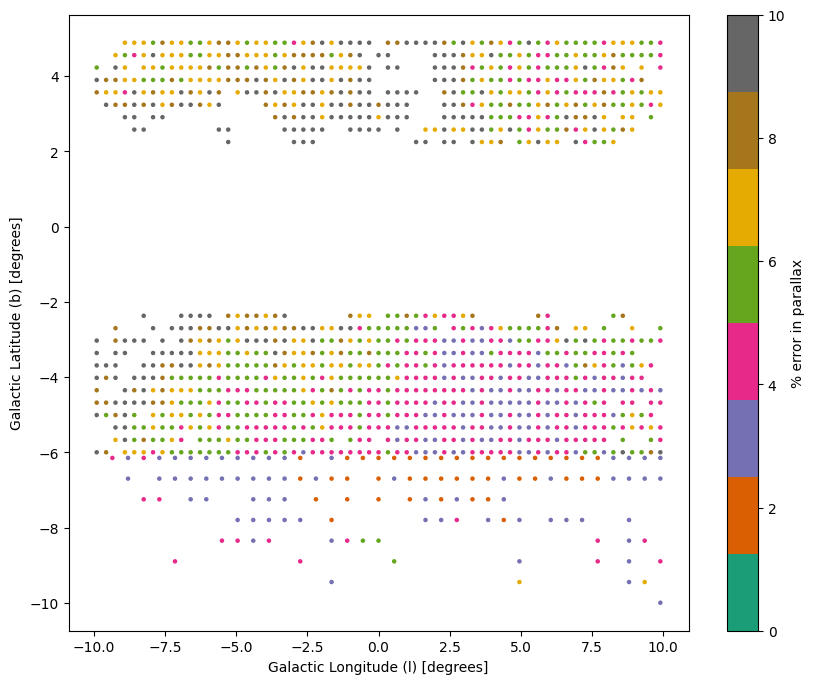

/var/folders/8l/p90_cj915l7dtkqz4wc5w59r0000gn/T/ipykernel_86192/909197146.py:77: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


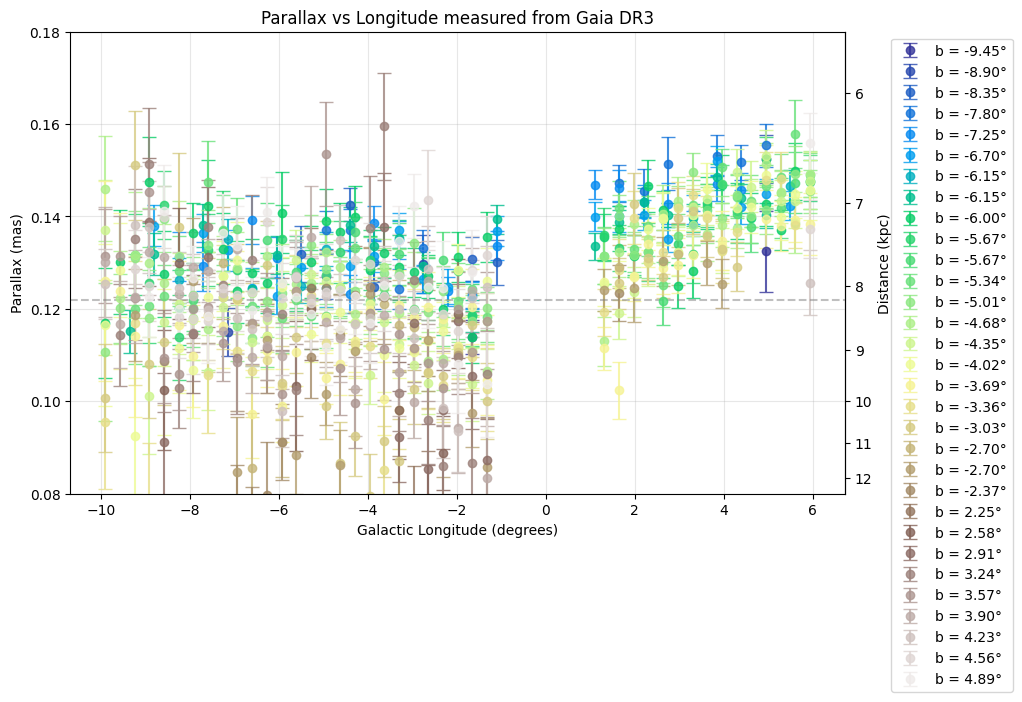

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from bar_parallax_analytic_model import bar_parallax3D, bar_parallax1D


dff1 = pd.read_csv('/Users/himanshuverma/Downloads/TotalAvg_Good_Single_Fits_s_0.33_level_0(3).csv')
dff2 = pd.read_csv('/Users/himanshuverma/Downloads/TotalAvg_Good_Single_Fits_s_0.55_level_0(1).csv')
dff = pd.concat([dff1, dff2], ignore_index=True).sort_values(by=['Latitude', 'Long']).reset_index(drop=True)


#draw 2d histogram of the data
plt.figure(figsize=(10, 8))
#plt.hist2d(dff['l'], dff['b'], bins=1000, cmap='plasma')
#plt.hist2d(dff['Long'], dff['Latitude'], bins=1000, cmap='plasma')
#plt.scatter(dff['l'], dff['b'], s=0.5, c=np.abs(dff['parallax_error']*100/dff['parallax']), cmap='Dark2', vmin=0,vmax=100)
plt.scatter(dff['Long'], dff['Latitude'], s=5, c=np.abs(dff['Mean Parallax Error']*100/dff['Mean Parallax']), cmap='Dark2', vmin=0,vmax=10)
plt.colorbar(label='% error in parallax')
#plt.colorbar(label='# of sources')
plt.xlabel('Galactic Longitude (l) [degrees]')
plt.ylabel('Galactic Latitude (b) [degrees]')
plt.show()

data=dff
df = data[(data['Magnitude Dispersion']<0.45) & (data['Magnitude Dispersion']>0.23) & (data['Magnitude Distinctness']>0.5) &
    (data['Color Dispersion']>0.1) & (data['Color Dispersion']<0.3) & (data['Mean Color']<2.2) 
    & (data['Long']>1) & (data['Long']<6) | (data['Long']<-1)#v7    
    #& (data['Long']<5)& (data['Long']>-5)#v5 and v6 without this cut
    ]
df.drop_duplicates()  # Keep first occurrence
df_u = df.drop_duplicates(keep='last')  # Keep last occurrence

#choose unique latitudes
unique_latitudes = df['Latitude'].unique()
unique_longitudes = df['Long'].unique()

fig = plt.figure(figsize=(10, 6))

#define user defined colors for each latitude
colors = plt.colormaps['terrain'](np.linspace(0, 1, len(unique_latitudes)+1))

ax = fig.add_subplot(1, 1, 1)
custom_params = {
    'sigma_x': 0.83,  # Longer bar major axis
    'sigma_y': 0.21,  # Shorter bar minor axis
    'sigma_z': 0.22,  # Thinner bar vertically
    'r_E': 8.16,       # Closer bar center
    's_max': 15.0,     # Max distance from us for averaging
    #'epsrel': 1e-6    # Relative error tolerance for integration
}
Al = np.linspace(-5, 5, 50)  # Galactic longitude range for plotting
for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]


    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']
    analytic_parallaxes = [bar_parallax3D(l, fixed_b_deg, 6.49, **custom_params) for l in unique_longitudes]
    ax.errorbar(longitude_range, parallax_data, 
                yerr=parallax_error, 
                fmt='o', alpha=0.8,
                color=colors[unique_latitudes.tolist().index(fixed_b_deg)], 
                capsize=5, markersize=6, label=f'b = {fixed_b_deg:.2f}°')
    #ax.plot(unique_longitudes, analytic_parallaxes, 
    #        '--',color=colors[unique_latitudes.tolist().index(fixed_b_deg)], alpha=0.7)
ax.set_xlabel('Galactic Longitude (degrees)')
ax.set_ylabel(f'Parallax (mas)')
ax.set_title(f'Parallax vs Longitude measured from Gaia DR3')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
#ax.set_xlim(-16, 16)
ax.set_ylim(0.08, 0.18)

ax.axhline(1/8.2, color='gray', linestyle='--', alpha=0.5)

axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))
axsec.set_ylabel('Distance (kpc)')

#fig.savefig(os.path.join(plots_dir, f'GaiaDR3_parallax_vs_longitude.png'), dpi=300)
plt.show()